|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 5:</h2>|<h1>Making It Fast<h1>|
|<h2>Section:</h2>|<h1>Sampling<h1>|
|<h2>Lecture:</h2>|<h1><b>The sampler becomes the bottleneck once the kernels are fast<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# The sampler becomes your bottleneck

Every request has its own temperature, its own top-p, its own seed. The
obvious implementation is a loop over the batch.

Once the kernels are fast, that loop is the slowest thing in the server, and
it is running on the CPU while the GPU waits.

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
VOCAB = 151936            # Qwen3

def random_batch(batch_size):
  """-> (logits, temperatures, top_ps), one row for each request."""
  return (torch.randn(batch_size, VOCAB, device=device),
          torch.rand(batch_size, device=device)*1.5 + 0.2,
          torch.rand(batch_size, device=device)*0.3 + 0.7)

BATCH = 64
torch.manual_seed(0)
logits, temperatures, top_ps = random_batch(BATCH)
print(f'{BATCH} requests, vocabulary of {VOCAB:,}')

64 requests, vocabulary of 151,936


### One request at a time

In [3]:
def top_p_probs(sorted_logits, top_ps):
  """Softmax over logits sorted from high to low. Keep the top-p nucleus,
  with the token that crosses p. -> the renormalized probabilities."""
  probs = F.softmax(sorted_logits, dim=-1)
  cumulative = probs.cumsum(dim=-1)
  probs = probs * ((cumulative - probs) < top_ps[..., None])
  return probs / probs.sum(dim=-1, keepdim=True)

def sample_loop(logits, temperatures, top_ps):
  """One request at a time: the Python loop of a first version."""
  tokens = torch.empty(len(logits), dtype=torch.long, device=logits.device)
  for row in range(len(logits)):
    sorted_logits, order = torch.sort(logits[row] / temperatures[row], descending=True)
    probs = top_p_probs(sorted_logits, top_ps[row])
    tokens[row] = order[torch.multinomial(probs, 1)]
  return tokens

loop_ms = cudalib.bench_ms(lambda: sample_loop(logits, temperatures, top_ps),
                           iters=10, warmup=3, best_of=2)
print(f'loop over the requests: {loop_ms:.2f} ms for {BATCH} requests')

loop over the requests: 9.87 ms for 64 requests


### All of them at once

Every step above is a per-row operation that torch already does batched. The
only reason it was a loop is that the parameters differ per row, and a column
vector fixes that.

In [4]:
def sample_batched(logits, temperatures, top_ps):
  """All requests in one pass: broadcast, not loop."""
  sorted_logits, order = torch.sort(logits / temperatures[:, None],
                                    dim=-1, descending=True)
  probs = top_p_probs(sorted_logits, top_ps)
  picked = torch.multinomial(probs, 1)
  return order.gather(1, picked).squeeze(1)

batched_ms = cudalib.bench_ms(lambda: sample_batched(logits, temperatures, top_ps),
                              iters=10, warmup=3, best_of=2)
print(f'loop over the requests: {loop_ms:7.2f} ms')
print(f'one batched pass:       {batched_ms:7.2f} ms')
print(f'\n{loop_ms/batched_ms:.0f}x, and the arithmetic did not change')

loop over the requests:    9.87 ms
one batched pass:          6.62 ms

1x, and the arithmetic did not change


### Does it scale the way you want?

In [5]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
loop_times, batched_times = [], []
for batch_size in batch_sizes:
  batch = random_batch(batch_size)
  loop_times.append(cudalib.bench_ms(lambda: sample_loop(*batch), iters=5, warmup=2))
  batched_times.append(cudalib.bench_ms(lambda: sample_batched(*batch), iters=10, warmup=3))
for batch_size, loop_ms, batched_ms in zip(batch_sizes, loop_times, batched_times):
  print(f'batch {batch_size:>4}: loop {loop_ms:7.2f} ms, batched {batched_ms:6.2f} ms  '
        f'({loop_ms/batched_ms:5.1f}x)')

batch    1: loop    0.19 ms, batched   0.19 ms  (  1.0x)
batch    2: loop    0.38 ms, batched   0.46 ms  (  0.8x)
batch    4: loop    1.06 ms, batched   0.53 ms  (  2.0x)
batch    8: loop    2.06 ms, batched   0.61 ms  (  3.4x)
batch   16: loop    3.97 ms, batched   1.12 ms  (  3.6x)
batch   32: loop    5.23 ms, batched   2.64 ms  (  2.0x)
batch   64: loop   10.75 ms, batched   5.95 ms  (  1.8x)
batch  128: loop   26.03 ms, batched  15.56 ms  (  1.7x)


The batched version wins, and then it stops to win. At batch 128 it still
needs fifteen milliseconds. That is longer than the whole decode step that
holds it.

So this is not a Python problem. It is real GPU work. The responsible line is
`torch.sort`. It sorts one hundred and fifty thousand numbers for each request
to find the few that matter.

### Stop sorting the vocabulary

Top-p needs the tokens in descending order only until the cumulative mass
reaches p. With p = 0.95 that is a few dozen tokens, never a hundred
thousand.

So take the top K first with `topk`, which does not sort what it discards,
and run the whole policy on those.

In [6]:
def sample_prefiltered(logits, temperatures, top_ps, top_k=64):
  """Sort only the top_k logits, not the full vocabulary."""
  sorted_logits, order = torch.topk(logits / temperatures[:, None], top_k, dim=-1)
  probs = top_p_probs(sorted_logits, top_ps)
  return order.gather(1, torch.multinomial(probs, 1)).squeeze(1)

prefiltered_times = []
for batch_size in batch_sizes:
  batch = random_batch(batch_size)
  prefiltered_times.append(cudalib.bench_ms(lambda: sample_prefiltered(*batch),
                                            iters=10, warmup=3))
print(f"{'batch':>6} {'loop':>9} {'batched':>9} {'top-k first':>12}")
for batch_size, loop_ms, batched_ms, prefiltered_ms in zip(
    batch_sizes, loop_times, batched_times, prefiltered_times):
  print(f'{batch_size:>6} {loop_ms:>8.2f}ms {batched_ms:>8.2f}ms {prefiltered_ms:>11.2f}ms')

 batch      loop   batched  top-k first
     1     0.19ms     0.19ms        0.33ms
     2     0.38ms     0.46ms        0.27ms
     4     1.06ms     0.53ms        0.27ms
     8     2.06ms     0.61ms        0.27ms
    16     3.97ms     1.12ms        0.26ms
    32     5.23ms     2.64ms        0.30ms
    64    10.75ms     5.95ms        0.58ms
   128    26.03ms    15.56ms        1.58ms


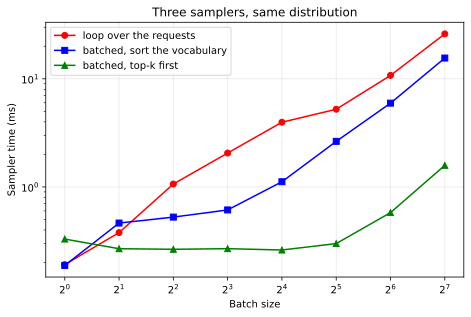

at batch 64: 19x faster than the loop, 10x faster than a full sort


In [7]:
plt.figure(figsize=(7.5,4.6))
plt.plot(batch_sizes, loop_times,        'ro-', label='loop over the requests')
plt.plot(batch_sizes, batched_times,     'bs-', label='batched, sort the vocabulary')
plt.plot(batch_sizes, prefiltered_times, 'g^-', label='batched, top-k first')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Batch size')
plt.ylabel('Sampler time (ms)')
plt.title('Three samplers, same distribution')
plt.legend()
plt.grid(alpha=.3)
plt.show()
at_64 = batch_sizes.index(64)
print(f'at batch 64: {loop_times[at_64]/prefiltered_times[at_64]:.0f}x faster than the loop, '
      f'{batched_times[at_64]/prefiltered_times[at_64]:.0f}x faster than a full sort')

### Two things that are now true, and one that is not quite

The sampler went from most of a decode step to a rounding error, and the
arithmetic never changed. Twice over: once by stopping the Python loop, once
by stopping the sort.

What is not quite true is that the third version is **exactly** the second.
It keeps the top K, so if a request ever needed more than K tokens to reach
its top-p, the tail is silently cut. With K = 64 and p = 0.95 that is rare,
and real engines either pick K conservatively or check and fall back.

That is a choice you should make on purpose and write down, not discover
later. Check it:

Do not test this on random logits. A vector of `randn` over one hundred and
fifty thousand entries is nothing like the output of a language model. The
model puts most of its mass on a few tokens. Use a real model.

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-0.6B')
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()
text = ('The history of computing began with mechanical calculators. Charles '
        'Babbage designed the Analytical Engine in 1837, and Ada Lovelace wrote '
        'what is considered the first computer program for it. ') * 8
token_ids = tokenizer(text, return_tensors='pt').input_ids[:, :512].cuda()
with torch.no_grad():
  real_logits = model(token_ids).logits[0].float()    # one distribution for each position
print(f'{real_logits.shape[0]} real next-token distributions')

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 9289.74it/s]

329 real next-token distributions


In [9]:
def nucleus_sizes(logits, temperature, top_p=0.95):
  """-> for each row, the number of tokens that top-p keeps."""
  sorted_probs, _ = torch.sort(F.softmax(logits/temperature, dim=-1),
                               dim=-1, descending=True)
  return (sorted_probs.cumsum(-1) < top_p).sum(-1) + 1

print(f"{'T':>5} {'median':>8} {'p90':>8} {'p99':>8} {'max':>8} {'K=64 cuts':>10} {'K=256 cuts':>11}")
for temperature in (0.6, 0.8, 1.0, 1.5):
  sizes = nucleus_sizes(real_logits, temperature)
  p90, p99 = (int(sizes.float().quantile(quantile)) for quantile in (0.90, 0.99))
  cut_64 = (sizes > 64).float().mean() * 100
  cut_256 = (sizes > 256).float().mean() * 100
  print(f'{temperature:>5} {sizes.median().item():>8} {p90:>8} {p99:>8} '
        f'{sizes.max().item():>8} {cut_64:>9.1f}% {cut_256:>10.1f}%')

    T   median      p90      p99      max  K=64 cuts  K=256 cuts
  0.6        1        2       15     1305       0.3%        0.3%
  0.8        1        4       66     9231       1.2%        0.9%
  1.0        1       11      842    27429       5.8%        3.0%


  1.5       28    18016    37989    76215      48.0%       42.2%


### Read the spread, not the median

At a normal temperature, the **median position needs one token**. The model
usually knows exactly what comes next, and top-p does nothing.

The maximum needs tens of thousands of tokens. At those positions the sentence
can go anywhere. Those are the positions where the sampling policy is the
whole point.

So the average tells you nothing here, and the tail tells you everything. K=64
is correct for more than 90% of tokens at T=1.0. At T=1.5 it cuts half of
them.

The failure is quiet. The output has a little less variety than the user asked
for, on the requests that asked for the most variety.

Pick K from the largest temperature that you permit. Do not pick it from the
median temperature. And write down that you did this, because the output never
tells you.

### The thing the batched version still gets wrong

Each request must have its own **seed**, so that a retry makes the same text.
`torch.multinomial` draws from one global generator. So two requests in the
same batch are not reproducible one by one.

Stage 13 makes you correct this. The JAX track gets the correct behaviour at
no cost, because JAX has no global RNG. A per-request seed is a per-row key
that you carry with the request.

    ./vc guide 13